# Sephora 화장품 가격·평점·성분 EDA·통계·시각화 실습

**데이터**: Sephora Products and Skincare Reviews  
**파일**: `product_info.csv`, `reviews_*.csv` (압축 해제 후 사용)

본 노트북은 Sephora 상품·리뷰 데이터로 분포·상관 EDA를 자동 생성하고,  
실험군·대조군(Sephora exclusive) 비교 통계와 가격·평점·성분 간 관계를 분석합니다.

In [1]:
# ============================================================
# 0. 라이브러리 불러오기 및 경로 설정 (압축 해제 포함)
# 과제 조건: zip 해제 후 product_info.csv, reviews_*.csv 사용
# ============================================================

# --- 표준 라이브러리 ---
# ast: ingredients 컬럼 문자열을 Python 리스트로 안전 파싱 (14단계)
import ast
# re: 성분명 공백 정규화
import re
# zipfile: Sephora Products and Skincare Reviews.zip 압축 해제
import zipfile
import warnings
# Counter: 성분 등장 빈도 TOP10 (16단계)
from collections import Counter
# Path: OS 독립적 파일 경로 (Windows/Linux 공통)
from pathlib import Path

# --- 데이터·시각화·통계 ---
# matplotlib: 히스토그램, 박스플롯, 산점도
import matplotlib.pyplot as plt
import numpy as np
# pandas: CSV 로드, groupby, 결측 처리
import pandas as pd
# seaborn: 상관 히트맵, 집단 박스플롯
import seaborn as sns
# scipy.stats: Shapiro, t검정, Mann-Whitney, Kruskal-Wallis
from scipy import stats

# scipy/pandas 경고 메시지 숨김 (출력 가독성; 분석 결과에는 영향 없음)
warnings.filterwarnings("ignore")

# --- 그래프 한글 표시 (Windows Malgun Gothic) ---
plt.rcParams["font.family"] = "Malgun Gothic"
# axes.unicode_minus=False: 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font="Malgun Gothic")

# 노트북과 같은 폴더를 데이터 루트로 사용
DATA_DIR = Path(".")
ZIP_PATH = DATA_DIR / "Sephora Products and Skincare Reviews.zip"
EXTRACT_DIR = DATA_DIR / "Sephora Products and Skincare Reviews"

# ------------------------------------------------------------
# zip 압축 해제 (이미 폴더가 있으면 재사용 → 재실행 시 시간 절약)
# ------------------------------------------------------------
if not EXTRACT_DIR.exists():
    if not ZIP_PATH.exists():
        raise FileNotFoundError(f"압축 파일을 찾을 수 없습니다: {ZIP_PATH.resolve()}")
    print(f"[0] 압축 해제 시작: {ZIP_PATH.name}")
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        # extractall: DATA_DIR 아래에 CSV 폴더 생성
        zf.extractall(DATA_DIR)
    print(f"[0] 압축 해제 완료: {EXTRACT_DIR.resolve()}")
else:
    print(f"[0] 데이터 폴더 존재: {EXTRACT_DIR.resolve()}")

# 이후 단계에서 공통으로 쓰는 파일 경로
PRODUCT_PATH = EXTRACT_DIR / "product_info.csv"
REVIEW_FILES = [
    EXTRACT_DIR / "reviews_0-250.csv",
    EXTRACT_DIR / "reviews_250-500.csv",
    EXTRACT_DIR / "reviews_500-750.csv",
    EXTRACT_DIR / "reviews_750-1250.csv",
    EXTRACT_DIR / "reviews_1250-end.csv",
]

print(f"[0] 상품 파일: {PRODUCT_PATH.name}")
print(f"[0] 리뷰 파일 수: {len(REVIEW_FILES)}")


[0] 데이터 폴더 존재: C:\MyCursorLab\02_바이오 데이터 EDA·통계·시각화 자동화\Sephora Products and Skincare Reviews
[0] 상품 파일: product_info.csv
[0] 리뷰 파일 수: 5


## 1. product_info.csv를 Pandas로 읽고 행 수·열 수·컬럼 목록 출력

In [2]:
# ============================================================
# 1. 상품 정보 로드 (과제 조건 1)
# product_info.csv → 행·열·컬럼 목록 출력
# ============================================================
products = pd.read_csv(PRODUCT_PATH)

# products.shape[0] = 행(상품 수), shape[1] = 열(변수 개수)
print(f"[1] 파일: {PRODUCT_PATH.name}")
print(f"[1] 행 수: {products.shape[0]:,}")
print(f"[1] 열 수: {products.shape[1]}")
print("[1] 컬럼 목록:")
for i, col in enumerate(products.columns, 1):
    print(f"  {i:2d}. {col}")

# Jupyter 전용: 상위 3행 미리보기 (실제 분석은 products DataFrame 전체 사용)
display(products.head(3))


[1] 파일: product_info.csv
[1] 행 수: 8,494
[1] 열 수: 27
[1] 컬럼 목록:
   1. product_id
   2. product_name
   3. brand_id
   4. brand_name
   5. loves_count
   6. rating
   7. reviews
   8. size
   9. variation_type
  10. variation_value
  11. variation_desc
  12. ingredients
  13. price_usd
  14. value_price_usd
  15. sale_price_usd
  16. limited_edition
  17. new
  18. online_only
  19. out_of_stock
  20. sephora_exclusive
  21. highlights
  22. primary_category
  23. secondary_category
  24. tertiary_category
  25. child_count
  26. child_max_price
  27. child_min_price


,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.6364,11.0,NaN,NaN,NaN,...,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
1,P473668,La Habana Eau de Parfum,6342,19-69,3827,4.1538,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,85.0,30.0
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253,4.2500,16.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0


## 2. 리뷰 CSV 5개를 하나로 합치고 행 수·컬럼 목록 출력

In [3]:
# ============================================================
# 2. 리뷰 CSV 5개 병합 (과제 조건 2)
# 용량 분할된 reviews_*.csv → 하나의 reviews 표
# ============================================================
# review_frames: 각 파일 DataFrame을 담을 리스트
review_frames = []
for path in REVIEW_FILES:
    if not path.exists():
        raise FileNotFoundError(f"리뷰 파일이 없습니다: {path}")
    # 일부 파일에 혼합 타입이 있어 low_memory=False 권장
    part = pd.read_csv(path, low_memory=False)
    print(f"[2] 로드: {path.name} → {part.shape[0]:,} rows × {part.shape[1]} cols")
    review_frames.append(part)

# pd.concat ignore_index=True → 합친 뒤 0,1,2… 인덱스 재부여
reviews = pd.concat(review_frames, ignore_index=True)

# 불필요한 인덱스 컬럼 정리 (CSV 저장 시 생긴 Unnamed: 0)
if "Unnamed: 0" in reviews.columns:
    reviews = reviews.drop(columns=["Unnamed: 0"])

print(f"\n[2] 병합 후 행 수: {reviews.shape[0]:,}")
print(f"[2] 병합 후 열 수: {reviews.shape[1]}")
print("[2] 컬럼 목록:")
for i, col in enumerate(reviews.columns, 1):
    print(f"  {i:2d}. {col}")

display(reviews.head(3))


[2] 로드: reviews_0-250.csv → 602,130 rows × 19 cols
[2] 로드: reviews_250-500.csv → 206,725 rows × 19 cols
[2] 로드: reviews_500-750.csv → 116,262 rows × 19 cols
[2] 로드: reviews_750-1250.csv → 119,317 rows × 19 cols
[2] 로드: reviews_1250-end.csv → 49,977 rows × 19 cols

[2] 병합 후 행 수: 1,094,411
[2] 병합 후 열 수: 18
[2] 컬럼 목록:
   1. author_id
   2. rating
   3. is_recommended
   4. helpfulness
   5. total_feedback_count
   6. total_neg_feedback_count
   7. total_pos_feedback_count
   8. submission_time
   9. review_text
  10. review_title
  11. skin_tone
  12. eye_color
  13. skin_type
  14. hair_color
  15. product_id
  16. product_name
  17. brand_name
  18. price_usd


,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
0,1741593524,5,1.0,1.0,2,0,2,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,NaN,brown,dry,black,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,19.0
1,31423088263,1,0.0,NaN,0,0,0,2023-03-21,I bought this lip mask after reading the revie...,Disappointed,NaN,NaN,NaN,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
2,5061282401,5,1.0,NaN,0,0,0,2023-03-21,My review title says it all! I get so excited ...,New Favorite Routine,light,brown,dry,blonde,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0


## 3. 상품·리뷰 각각의 결측 개수와 결측 비율 출력

In [4]:
# ============================================================
# 3. 결측 현황 (과제 조건 3)
# 상품·리뷰 각각 컬럼별 결측 개수·비율(%)
# ============================================================
def missing_summary(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """컬럼별 결측 개수·비율 요약표 생성"""
    # isna().sum(): 컬럼별 NaN 개수 / mean()*100: 결측 비율(%)
    miss = df.isna().sum()
    ratio = df.isna().mean() * 100
    out = pd.DataFrame({"결측개수": miss, "결측비율(%)": ratio.round(2)})
    out = out[out["결측개수"] > 0].sort_values("결측개수", ascending=False)
    print(f"[{name}] 전체 행: {len(df):,} | 결측이 있는 컬럼: {len(out)}")
    print(f"[{name}] 전체 결측 셀 수: {df.isna().sum().sum():,}")
    return out

print("=" * 60)
print("[3] 상품(product_info) 결측")
print("=" * 60)
product_missing = missing_summary(products, "3-상품")
display(product_missing)

print("\n" + "=" * 60)
print("[3] 리뷰(reviews) 결측")
print("=" * 60)
review_missing = missing_summary(reviews, "3-리뷰")
display(review_missing)


[3] 상품(product_info) 결측
[3-상품] 전체 행: 8,494 | 결측이 있는 컬럼: 14
[3-상품] 전체 결측 셀 수: 44,370


,결측개수,결측비율(%)
sale_price_usd,8224,96.82
value_price_usd,8043,94.69
variation_desc,7244,85.28
child_max_price,5740,67.58
child_min_price,5740,67.58
highlights,2207,25.98
size,1631,19.20
variation_value,1598,18.81
variation_type,1444,17.00
tertiary_category,990,11.66



[3] 리뷰(reviews) 결측
[3-리뷰] 전체 행: 1,094,411 | 결측이 있는 컬럼: 8
[3-리뷰] 전체 결측 셀 수: 1,760,170


,결측개수,결측비율(%)
helpfulness,561592,51.31
review_title,310654,28.39
hair_color,226768,20.72
eye_color,209628,19.15
skin_tone,170539,15.58
is_recommended,167988,15.35
skin_type,111557,10.19
review_text,1444,0.13


## 4. price_usd, rating, reviews, loves_count 기술통계

In [5]:
# ============================================================
# 4. 주요 수치형 변수 기술통계 (과제 조건 4)
# price_usd, rating, reviews, loves_count → describe()
# ============================================================
num_cols = ["price_usd", "rating", "reviews", "loves_count"]
# describe(): count, mean, std, min, 25%, 50%, 75%, max
# .T(전치): 변수가 행으로 오도록 표 읽기 쉽게
desc = products[num_cols].describe().T
desc = desc.rename(
    columns={
        "count": "개수",
        "mean": "평균",
        "std": "표준편차",
        "min": "최솟값",
        "25%": "25%",
        "50%": "50%(중앙값)",
        "75%": "75%",
        "max": "최댓값",
    }
)

print("[4] price_usd, rating, reviews, loves_count 기술통계")
display(desc.round(3))


[4] price_usd, rating, reviews, loves_count 기술통계


,개수,평균,표준편차,최솟값,25%,50%(중앙값),75%,최댓값
price_usd,8494.0,51.656,53.669,3.0,25.000,35.000,58.000,1900.0
rating,8216.0,4.195,0.517,1.0,3.982,4.289,4.531,5.0
reviews,8216.0,448.546,1101.983,1.0,26.000,122.000,418.000,21281.0
loves_count,8494.0,29179.566,66092.123,0.0,3758.000,9880.000,26841.250,1401068.0


## 5. 가격·평점·리뷰 수 분포 히스토그램

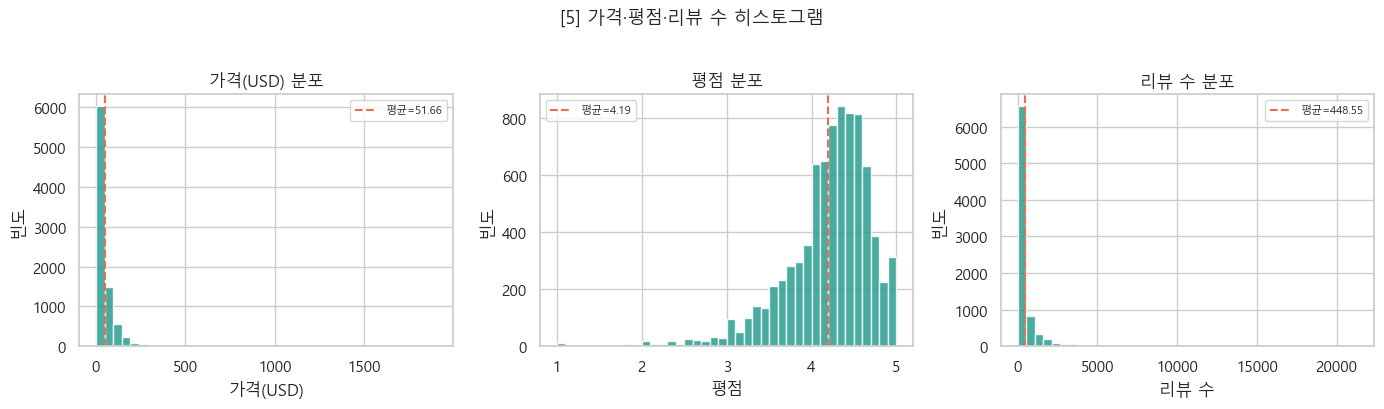

[5] 히스토그램 생성 완료
  - price_usd: n=8,494, mean=51.656, median=35.000
  - rating: n=8,216, mean=4.195, median=4.289
  - reviews: n=8,216, mean=448.546, median=122.000


In [6]:
# ============================================================
# 5. 분포 히스토그램 (과제 조건 5)
# 가격·평점·리뷰 수의 값 구간별 빈도
# ============================================================
hist_cols = ["price_usd", "rating", "reviews"]
titles = {"price_usd": "가격(USD)", "rating": "평점", "reviews": "리뷰 수"}

# subplots(1,3): 1행 3열 서브플롯
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, hist_cols):
    data = products[col].dropna()
    ax.hist(data, bins=40, color="#2a9d8f", edgecolor="white", alpha=0.85)
    ax.set_title(f"{titles[col]} 분포")
    ax.set_xlabel(titles[col])
    ax.set_ylabel("빈도")
    # axvline: 산술평균 위치 (치우친 분포에서는 중앙값과 차이 날 수 있음)
    ax.axvline(data.mean(), color="#e76f51", linestyle="--", linewidth=1.5, label=f"평균={data.mean():.2f}")
    ax.legend(fontsize=8)

fig.suptitle("[5] 가격·평점·리뷰 수 히스토그램", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("[5] 히스토그램 생성 완료")
for col in hist_cols:
    s = products[col].dropna()
    print(f"  - {col}: n={len(s):,}, mean={s.mean():.3f}, median={s.median():.3f}")


## 6. 가격·평점·리뷰 수 이상치 박스플롯

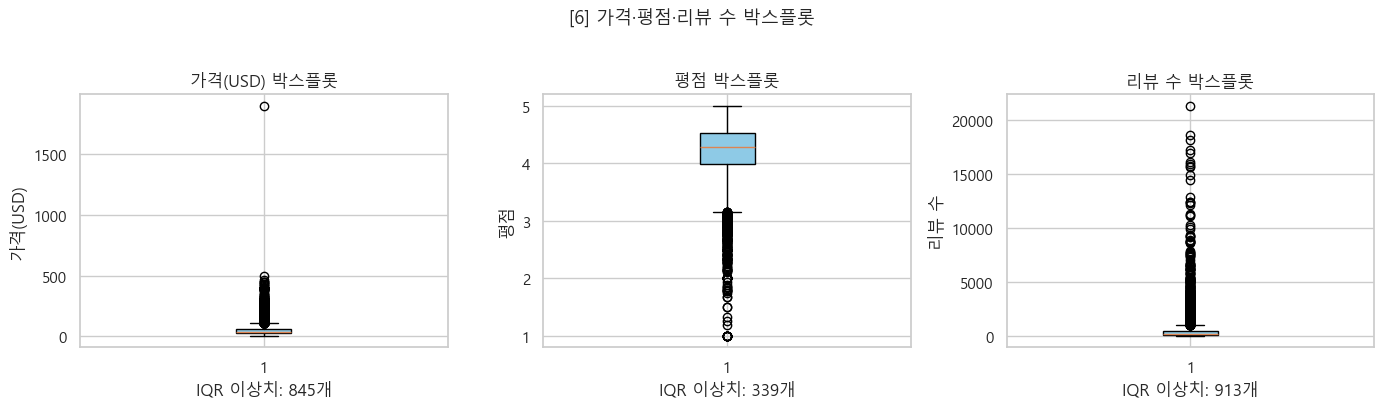

[6] 박스플롯 생성 완료 (IQR 기준 이상치 개수는 각 축 라벨 참고)


In [7]:
# ============================================================
# 6. 이상치 확인용 박스플롯 (과제 조건 6)
# Tukey IQR 규칙: Q1-1.5*IQR, Q3+1.5*IQR 밖을 이상치로 카운트
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, hist_cols):
    data = products[col].dropna()
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor="#8ecae6"))
    ax.set_title(f"{titles[col]} 박스플롯")
    ax.set_ylabel(titles[col])

    # IQR 기준 이상치 개수
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    n_out = ((data < q1 - 1.5 * iqr) | (data > q3 + 1.5 * iqr)).sum()
    ax.set_xlabel(f"IQR 이상치: {n_out:,}개")

fig.suptitle("[6] 가격·평점·리뷰 수 박스플롯", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("[6] 박스플롯 생성 완료 (IQR 기준 이상치 개수는 각 축 라벨 참고)")


## 7. 수치형 변수 상관계수 행렬과 상관 히트맵

[7] 피어슨 상관계수 행렬


,price_usd,rating,reviews,loves_count,limited_edition,new,online_only,out_of_stock,sephora_exclusive
price_usd,1.000,0.057,-0.055,-0.090,0.046,0.029,0.092,-0.022,-0.141
rating,0.057,1.000,0.070,0.042,-0.051,0.102,-0.022,-0.047,0.019
reviews,-0.055,0.070,1.000,0.684,-0.081,-0.055,-0.141,-0.064,-0.026
loves_count,-0.090,0.042,0.684,1.000,-0.069,-0.076,-0.164,-0.054,0.041
limited_edition,0.046,-0.051,-0.081,-0.069,1.000,0.156,0.061,0.162,0.067
new,0.029,0.102,-0.055,-0.076,0.156,1.000,0.043,0.014,0.067
online_only,0.092,-0.022,-0.141,-0.164,0.061,0.043,1.000,0.002,-0.101
out_of_stock,-0.022,-0.047,-0.064,-0.054,0.162,0.014,0.002,1.000,0.025
sephora_exclusive,-0.141,0.019,-0.026,0.041,0.067,0.067,-0.101,0.025,1.000


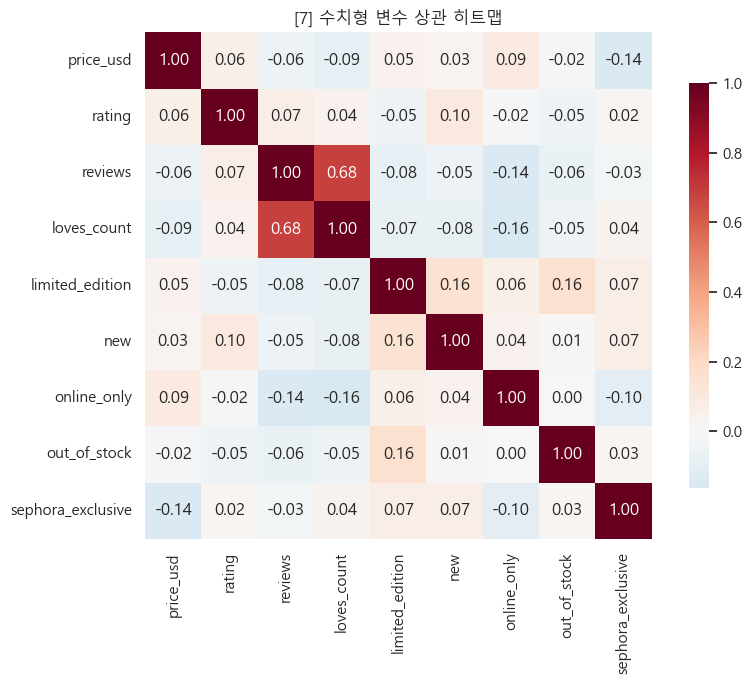

[7] price_usd ↔ rating 상관: 0.057
[7] price_usd ↔ reviews 상관: -0.055
[7] rating ↔ reviews 상관: 0.070
[7] reviews ↔ loves_count 상관: 0.684


In [8]:
# ============================================================
# 7. 수치형 상관분석 자동 생성 (과제 조건 7)
# 피어슨 r 행렬 + seaborn 히트맵
# ============================================================
# 분석에 쓸 주요 수치형 컬럼만 선택
corr_cols = [
    "price_usd", "rating", "reviews", "loves_count",
    "limited_edition", "new", "online_only", "out_of_stock", "sephora_exclusive",
]
# products에 없는 열 이름 방어
corr_cols = [c for c in corr_cols if c in products.columns]

# pearson: -1~+1 선형 상관
corr_mat = products[corr_cols].corr(method="pearson")
print("[7] 피어슨 상관계수 행렬")
display(corr_mat.round(3))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_mat,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    ax=ax,
    cbar_kws={"shrink": 0.8},
)
ax.set_title("[7] 수치형 변수 상관 히트맵")
plt.tight_layout()
plt.show()

# 가격·평점 핵심 상관만 요약 (인과 아님, 함께 변하는 경향만)
print(f"[7] price_usd ↔ rating 상관: {corr_mat.loc['price_usd', 'rating']:.3f}")
print(f"[7] price_usd ↔ reviews 상관: {corr_mat.loc['price_usd', 'reviews']:.3f}")
print(f"[7] rating ↔ reviews 상관: {corr_mat.loc['rating', 'reviews']:.3f}")
print(f"[7] reviews ↔ loves_count 상관: {corr_mat.loc['reviews', 'loves_count']:.3f}")


## 8. primary_category별 상품 수·평균 가격·평균 평점·중앙값 가격

In [9]:
# ============================================================
# 8. 카테고리별 요약표 (과제 조건 8)
# primary_category별 상품 수, 평균/중앙값 가격, 평균 평점
# ============================================================
cat_summary = (
    products.groupby("primary_category", dropna=False)
    .agg(
        상품수=("product_id", "count"),
        평균가격=("price_usd", "mean"),
        평균평점=("rating", "mean"),
        중앙값가격=("price_usd", "median"),
    )
    .sort_values("상품수", ascending=False)
    .round(3)
)

print("[8] primary_category별 요약")
display(cat_summary)


[8] primary_category별 요약


,상품수,평균가격,평균평점,중앙값가격
primary_category,,,,
Skincare,2420,60.512,4.229,44.0
Makeup,2369,32.758,4.147,29.0
Hair,1464,42.787,4.201,32.0
Fragrance,1432,87.263,4.231,80.0
Bath & Body,405,42.233,4.195,38.0
Mini Size,288,21.398,4.006,18.0
Men,60,33.200,4.505,30.0
Tools & Brushes,52,31.922,4.271,19.5
Gifts,4,50.000,4.563,50.0


## 9. Sephora exclusive 집단 정의 및 표본 수

- **비교 집단(실험군)**: `sephora_exclusive == 1`
- **기준 집단(대조군)**: `sephora_exclusive == 0`

In [10]:
# ============================================================
# 9. 실험군·대조군 정의 (과제 조건 9)
# 비교(실험): sephora_exclusive==1 / 기준(대조): ==0
# ============================================================
group_cmp = products[products["sephora_exclusive"] == 1].copy()  # 비교 집단
group_base = products[products["sephora_exclusive"] == 0].copy()  # 기준 집단

print("[9] 집단 정의")
print(f"  - 비교 집단 (sephora_exclusive=1): {len(group_cmp):,}개")
print(f"  - 기준 집단 (sephora_exclusive=0): {len(group_base):,}개")
print(f"  - 합계: {len(group_cmp) + len(group_base):,}개 (전체 {len(products):,}개)")
print("\n[9] 집단별 가격·평점 평균")
print(f"  - 비교 집단 평균 가격: {group_cmp['price_usd'].mean():.3f}, 평균 평점: {group_cmp['rating'].mean():.3f}")
print(f"  - 기준 집단 평균 가격: {group_base['price_usd'].mean():.3f}, 평균 평점: {group_base['rating'].mean():.3f}")


[9] 집단 정의
  - 비교 집단 (sephora_exclusive=1): 2,373개
  - 기준 집단 (sephora_exclusive=0): 6,121개
  - 합계: 8,494개 (전체 8,494개)

[9] 집단별 가격·평점 평균
  - 비교 집단 평균 가격: 39.543, 평균 평점: 4.210
  - 기준 집단 평균 가격: 56.351, 평균 평점: 4.188


## 10. 두 집단의 가격·평점 박스플롯 비교

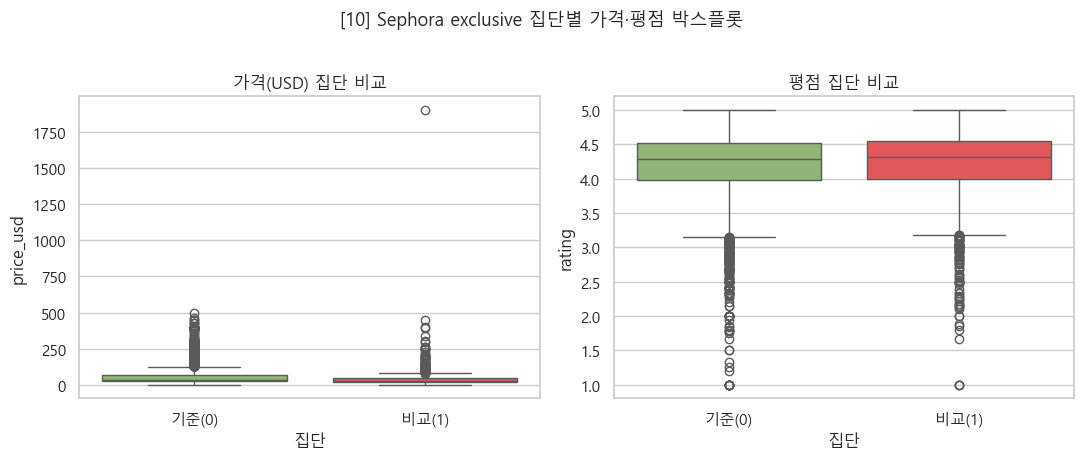

[10] 박스플롯 생성 완료


In [11]:
# ============================================================
# 10. 집단별 박스플롯 (과제 조건 10)
# 두 집단의 가격·평점 분포 형태 비교
# ============================================================
plot_df = products.dropna(subset=["sephora_exclusive"]).copy()
plot_df["집단"] = plot_df["sephora_exclusive"].map({0: "기준(0)", 1: "비교(1)"})

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.boxplot(data=plot_df, x="집단", y="price_usd", ax=axes[0], palette=["#90be6d", "#f94144"])
axes[0].set_title("가격(USD) 집단 비교")
axes[0].set_ylabel("price_usd")

sns.boxplot(data=plot_df, x="집단", y="rating", ax=axes[1], palette=["#90be6d", "#f94144"])
axes[1].set_title("평점 집단 비교")
axes[1].set_ylabel("rating")

fig.suptitle("[10] Sephora exclusive 집단별 가격·평점 박스플롯", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("[10] 박스플롯 생성 완료")


## 11–12. 정규성 확인 → t검정 또는 Mann-Whitney U검정 + 효과크기·해석

In [12]:
# ============================================================
# 11–12. 정규성 검정 후 적절한 집단 비교 + 효과크기 (과제 조건 11–12)
# Shapiro-Wilk → (정규) Welch t + Cohen's d / (비정규) Mann-Whitney + rank-biserial
# ============================================================
# ALPHA=0.05: 유의수준 (p-value가 이보다 작으면 "차이 있음"으로 해석)
ALPHA = 0.05


def shapiro_safe(x: pd.Series, max_n: int = 5000):
    """표본이 크면 랜덤 서브샘플로 Shapiro-Wilk 수행"""
    x = x.dropna().astype(float)
    if len(x) < 3:
        return np.nan, np.nan, len(x)
    # Shapiro는 n 상한 → 최대 max_n개 무작위 추출, random_state=42 재현
    sample = x.sample(n=min(len(x), max_n), random_state=42)
    stat, p = stats.shapiro(sample)
    return stat, p, len(sample)


def cohens_d(a: pd.Series, b: pd.Series) -> float:
    """독립표본 Cohen's d"""
    a, b = a.dropna().astype(float), b.dropna().astype(float)
    na, nb = len(a), len(b)
    # pooled std: 두 집단 분산의 가중 평균 (Cohen's d 분모)
    pooled = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (a.mean() - b.mean()) / pooled if pooled > 0 else np.nan


def rank_biserial(u_stat: float, n1: int, n2: int) -> float:
    """Mann-Whitney U의 rank-biserial 상관계수"""
    return 1 - (2 * u_stat) / (n1 * n2)


def compare_groups(var_name: str, a: pd.Series, b: pd.Series):
    """정규성 → t검정 또는 Mann-Whitney, 결과 dict 반환"""
    a = a.dropna().astype(float)
    b = b.dropna().astype(float)

    sh_a, p_a, n_sa = shapiro_safe(a)
    sh_b, p_b, n_sb = shapiro_safe(b)
    both_normal = (p_a >= ALPHA) and (p_b >= ALPHA)

    print(f"\n{'=' * 60}")
    print(f"[11] 변수: {var_name}")
    print(f"  비교 집단 n={len(a):,}, 기준 집단 n={len(b):,}")
    print(f"  Shapiro(비교): W={sh_a:.4f}, p={p_a:.4g} (샘플 n={n_sa})")
    print(f"  Shapiro(기준): W={sh_b:.4f}, p={p_b:.4g} (샘플 n={n_sb})")

    if both_normal:
        # 등분산 가정 없이 Welch t-test
        stat, p = stats.ttest_ind(a, b, equal_var=False, nan_policy="omit")
        effect = cohens_d(a, b)
        test_name = "Welch 독립표본 t검정"
        effect_name = "Cohen's d"
    else:
        # Mann-Whitney: 순위 기반 비모수 (치우친 분포에 적합)
        stat, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        effect = rank_biserial(stat, len(a), len(b))
        test_name = "Mann-Whitney U검정"
        effect_name = "rank-biserial r"

    print(f"[12] 선택 검정: {test_name}")
    print(f"[12] 검정 통계량: {stat:.4f}")
    print(f"[12] p-value: {p:.4g}")
    print(f"[12] 효과크기({effect_name}): {effect:.4f}")

    mean_diff = a.mean() - b.mean()
    if p < ALPHA:
        interp = (
            f"[12] 해석: {var_name}에서 비교 집단과 기준 집단 간 차이가 "
            f"통계적으로 유의하다(p={p:.4g} < {ALPHA}). "
            f"비교 집단 평균이 기준 집단보다 {mean_diff:+.3f}이다."
        )
    else:
        interp = (
            f"[12] 해석: {var_name}에서 비교 집단과 기준 집단 간 차이가 "
            f"통계적으로 유의하지 않다(p={p:.4g} ≥ {ALPHA}). "
            f"평균 차이(비교−기준)는 {mean_diff:+.3f}이다."
        )
    print(interp)

    return {
        "변수": var_name,
        "검정": test_name,
        "통계량": stat,
        "p_value": p,
        "효과크기": effect,
        "효과크기명": effect_name,
        "해석": interp,
    }


results_12 = [
    compare_groups("price_usd", group_cmp["price_usd"], group_base["price_usd"]),
    compare_groups("rating", group_cmp["rating"], group_base["rating"]),
]

print("\n[12] 검정 결과 요약표")
display(pd.DataFrame(results_12)[["변수", "검정", "통계량", "p_value", "효과크기", "효과크기명"]].round(4))



[11] 변수: price_usd
  비교 집단 n=2,373, 기준 집단 n=6,121
  Shapiro(비교): W=0.3454, p=2.427e-68 (샘플 n=2373)
  Shapiro(기준): W=0.6937, p=6.58e-70 (샘플 n=5000)
[12] 선택 검정: Mann-Whitney U검정
[12] 검정 통계량: 5544215.5000
[12] p-value: 1.944e-64
[12] 효과크기(rank-biserial r): 0.2366
[12] 해석: price_usd에서 비교 집단과 기준 집단 간 차이가 통계적으로 유의하다(p=1.944e-64 < 0.05). 비교 집단 평균이 기준 집단보다 -16.808이다.

[11] 변수: rating
  비교 집단 n=2,310, 기준 집단 n=5,906
  Shapiro(비교): W=0.9056, p=1.317e-35 (샘플 n=2310)
  Shapiro(기준): W=0.9048, p=2.191e-48 (샘플 n=5000)
[12] 선택 검정: Mann-Whitney U검정
[12] 검정 통계량: 7032163.0000
[12] p-value: 0.02923
[12] 효과크기(rank-biserial r): -0.0309
[12] 해석: rating에서 비교 집단과 기준 집단 간 차이가 통계적으로 유의하다(p=0.02923 < 0.05). 비교 집단 평균이 기준 집단보다 +0.022이다.

[12] 검정 결과 요약표


,변수,검정,통계량,p_value,효과크기,효과크기명
0,price_usd,Mann-Whitney U검정,5544215.5,0.0000,0.2366,rank-biserial r
1,rating,Mann-Whitney U검정,7032163.0,0.0292,-0.0309,rank-biserial r


## 13. primary_category(3개 이상)에 대한 Kruskal-Wallis 검정

In [13]:
# ============================================================
# 13. 카테고리 간 가격·평점 차이 (Kruskal-Wallis) (과제 조건 13)
# 3개 이상 범주(primary_category) → 순위 기반 다집단 검정
# p 유의 시 "어딘가는 다름" (어느 쌍인지는 사후검정 필요)
# ============================================================
kw_df = products.dropna(subset=["primary_category"]).copy()

# 표본이 있는 카테고리만 사용 (과제: 범주 3개 이상)
cats = kw_df["primary_category"].value_counts()
valid_cats = cats[cats >= 1].index.tolist()
print(f"[13] 사용 카테고리 수: {len(valid_cats)} (≥3 필요)")
print("[13] 카테고리:", valid_cats)

if len(valid_cats) < 3:
    raise ValueError("Kruskal-Wallis 검정을 위한 카테고리가 3개 미만입니다.")


def kruskal_by_category(var_name: str):
    # groups: 카테고리별 1차원 numpy 배열 리스트
    groups = [
        kw_df.loc[kw_df["primary_category"] == c, var_name].dropna().astype(float).values
        for c in valid_cats
    ]
    groups = [g for g in groups if len(g) > 0]
    H, p = stats.kruskal(*groups)
    print(f"\n[13] {var_name} Kruskal-Wallis")
    print(f"  H 통계량: {H:.4f}")
    print(f"  p-value: {p:.4g}")
    if p < ALPHA:
        print(f"  해석: primary_category에 따라 {var_name} 분포에 유의한 차이가 있다.")
    else:
        print(f"  해석: primary_category에 따른 {var_name} 분포 차이는 유의하지 않다.")
    return H, p


H_price, p_price = kruskal_by_category("price_usd")
H_rating, p_rating = kruskal_by_category("rating")


[13] 사용 카테고리 수: 9 (≥3 필요)
[13] 카테고리: ['Skincare', 'Makeup', 'Hair', 'Fragrance', 'Bath & Body', 'Mini Size', 'Men', 'Tools & Brushes', 'Gifts']

[13] price_usd Kruskal-Wallis
  H 통계량: 1659.4560
  p-value: 0
  해석: primary_category에 따라 price_usd 분포에 유의한 차이가 있다.

[13] rating Kruskal-Wallis
  H 통계량: 117.0168
  p-value: 1.368e-21
  해석: primary_category에 따라 rating 분포에 유의한 차이가 있다.


## 14. ingredients가 있는 상품만 남기고 상품별 성분 개수 계산

In [14]:
# ============================================================
# 14. 성분 파싱 및 성분 개수 (과제 조건 14)
# ingredients 문자열 → 리스트 → ingredient_count
# ============================================================
def parse_ingredients(raw) -> list[str]:
    """ingredients 문자열(리스트 형태)을 개별 성분 리스트로 변환"""
    if pd.isna(raw):
        return []
    text = str(raw).strip()
    if not text:
        return []

    try:
        # literal_eval: eval과 달리 리터럴만 파싱 (보안·안정)
        parsed = ast.literal_eval(text)
        if isinstance(parsed, list):
            chunks = [str(x) for x in parsed]
        else:
            chunks = [str(parsed)]
    except (ValueError, SyntaxError):
        chunks = [text]

    ingredients = []
    for chunk in chunks:
        # "제품명: 성분1, 성분2" 형태면 콜론 뒤만 사용
        if ":" in chunk:
            chunk = chunk.split(":", 1)[1]
        for token in chunk.split(","):
            name = token.strip()
            # 괄호 안 설명 제거 (선택적으로 단순화)
            name = re.sub(r"\s+", " ", name)
            if name and len(name) > 1:
                ingredients.append(name)
    return ingredients


ing_df = products.dropna(subset=["ingredients"]).copy()
print(f"[14] ingredients 있는 상품: {len(ing_df):,} / 전체 {len(products):,}")

ing_df["ingredient_list"] = ing_df["ingredients"].apply(parse_ingredients)
ing_df["ingredient_count"] = ing_df["ingredient_list"].apply(len)

# 성분 0개인 행은 파싱 실패로 보고 제외
before = len(ing_df)
ing_df = ing_df[ing_df["ingredient_count"] > 0].copy()
print(f"[14] 파싱 후 유효 상품: {len(ing_df):,} (제외 {before - len(ing_df):,})")
print("[14] 성분 개수 기술통계:")
print(ing_df["ingredient_count"].describe().round(2))

display(ing_df[["product_name", "price_usd", "rating", "ingredient_count"]].head())


[14] ingredients 있는 상품: 7,549 / 전체 8,494
[14] 파싱 후 유효 상품: 7,544 (제외 5)
[14] 성분 개수 기술통계:
count    7544.00
mean       31.84
std        31.18
min         1.00
25%        16.00
50%        25.00
75%        39.00
max       720.00
Name: ingredient_count, dtype: float64


,product_name,price_usd,rating,ingredient_count
0,Fragrance Discovery Set,35.0,3.6364,87
1,La Habana Eau de Parfum,195.0,4.1538,13
2,Rainbow Bar Eau de Parfum,195.0,4.2500,12
3,Kasbah Eau de Parfum,195.0,4.4762,12
4,Purple Haze Eau de Parfum,195.0,3.2308,12


## 15. 성분 개수와 price_usd·rating 산점도 및 상관계수

[15] 성분 개수 ↔ price_usd 피어슨 상관: 0.0562
[15] 성분 개수 ↔ rating 피어슨 상관: 0.0192


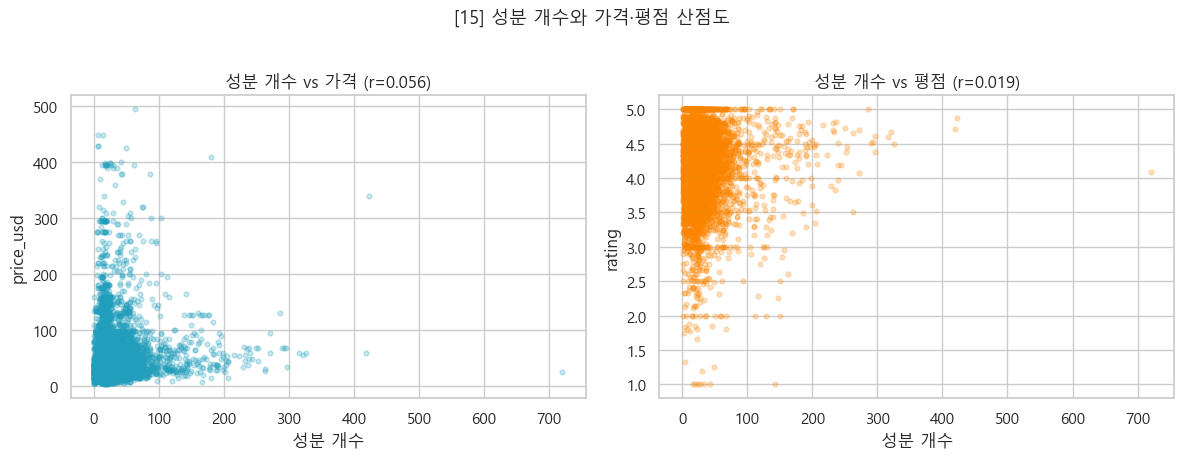

In [15]:
# ============================================================
# 15. 성분 개수 ↔ 가격·평점 (과제 조건 15)
# 산점도 + 피어슨 상관계수 r
# ============================================================
corr_price = ing_df["ingredient_count"].corr(ing_df["price_usd"])
corr_rating = ing_df["ingredient_count"].corr(ing_df["rating"])

print(f"[15] 성분 개수 ↔ price_usd 피어슨 상관: {corr_price:.4f}")
print(f"[15] 성분 개수 ↔ rating 피어슨 상관: {corr_rating:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(ing_df["ingredient_count"], ing_df["price_usd"], alpha=0.25, s=12, color="#219ebc")
axes[0].set_xlabel("성분 개수")
axes[0].set_ylabel("price_usd")
axes[0].set_title(f"성분 개수 vs 가격 (r={corr_price:.3f})")

valid_rating = ing_df.dropna(subset=["rating"])
axes[1].scatter(valid_rating["ingredient_count"], valid_rating["rating"], alpha=0.25, s=12, color="#fb8500")
axes[1].set_xlabel("성분 개수")
axes[1].set_ylabel("rating")
axes[1].set_title(f"성분 개수 vs 평점 (r={corr_rating:.3f})")

fig.suptitle("[15] 성분 개수와 가격·평점 산점도", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 16. 상위 10개 성분 포함 여부에 따른 평균 가격·평점

In [16]:
# ============================================================
# 16. 빈도 상위 10 성분 × 포함 여부별 평균 가격·평점 (과제 조건 16)
# Counter로 전체 등장 빈도 → TOP10 → 포함/미포함 그룹 평균 비교
# ============================================================
# 대소문자 통일해 빈도 집계
all_ings = []
for lst in ing_df["ingredient_list"]:
    all_ings.extend([x.lower() for x in lst])

top10 = Counter(all_ings).most_common(10)
print("[16] 등장 빈도 상위 10 성분")
for i, (name, cnt) in enumerate(top10, 1):
    print(f"  {i:2d}. {name} ({cnt:,}회)")

rows = []
for name, cnt in top10:
    mask = ing_df["ingredient_list"].apply(lambda xs: name in [x.lower() for x in xs])
    has = ing_df[mask]
    no = ing_df[~mask]
    rows.append({
        "성분": name,
        "등장횟수": cnt,
        "포함_상품수": len(has),
        "포함_평균가격": has["price_usd"].mean(),
        "미포함_평균가격": no["price_usd"].mean(),
        "포함_평균평점": has["rating"].mean(),
        "미포함_평균평점": no["rating"].mean(),
    })

top10_table = pd.DataFrame(rows).round(3)
print("\n[16] 성분 포함 여부에 따른 평균 가격·평점")
display(top10_table)


[16] 등장 빈도 상위 10 성분
   1. glycerin (4,003회)
   2. phenoxyethanol (3,420회)
   3. limonene (2,521회)
   4. caprylyl glycol (2,409회)
   5. tocopherol (2,402회)
   6. linalool (2,320회)
   7. ethylhexylglycerin (2,192회)
   8. butylene glycol (2,184회)
   9. citric acid (2,129회)
  10. dimethicone (1,982회)

[16] 성분 포함 여부에 따른 평균 가격·평점


,성분,등장횟수,포함_상품수,포함_평균가격,미포함_평균가격,포함_평균평점,미포함_평균평점
0,glycerin,4003,3503,49.301,52.519,4.206,4.195
1,phenoxyethanol,3420,2750,46.323,53.722,4.163,4.221
2,limonene,2521,2247,69.846,43.041,4.267,4.172
3,caprylyl glycol,2409,1852,49.061,51.664,4.195,4.201
4,tocopherol,2402,2053,51.287,50.927,4.224,4.191
5,linalool,2320,2104,72.183,42.842,4.254,4.179
6,ethylhexylglycerin,2192,1703,48.533,51.752,4.196,4.201
7,butylene glycol,2184,1993,51.828,50.737,4.176,4.209
8,citric acid,2129,1953,47.905,52.115,4.198,4.201
9,dimethicone,1982,1474,53.340,50.463,4.190,4.202


## 17. 가격·평점·성분 개수 관계 한 장 요약 시각화

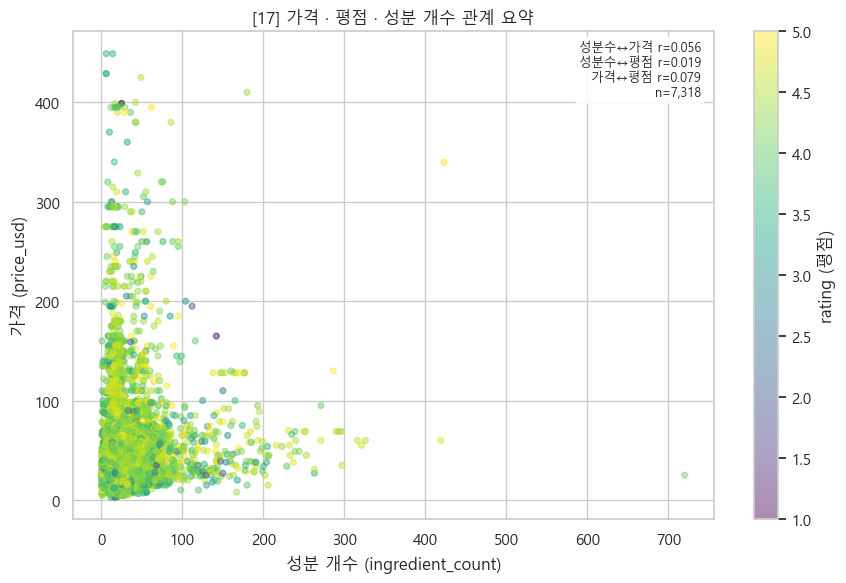

[17] 요약 시각화 생성 완료


In [17]:
# ============================================================
# 17. 3변수 관계 요약 시각화 (산점도 + 색상=평점) (과제 조건 17)
# x=성분개수, y=가격, color=평점 → 한 장에 요약
# ============================================================
viz = ing_df.dropna(subset=["rating", "price_usd", "ingredient_count"]).copy()

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(
    viz["ingredient_count"],
    viz["price_usd"],
    c=viz["rating"],
    cmap="viridis",
    alpha=0.45,
    s=18,
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("rating (평점)")
ax.set_xlabel("성분 개수 (ingredient_count)")
ax.set_ylabel("가격 (price_usd)")
ax.set_title("[17] 가격 · 평점 · 성분 개수 관계 요약")

# 상관 요약 텍스트
txt = (
    f"성분수↔가격 r={corr_price:.3f}\n"
    f"성분수↔평점 r={corr_rating:.3f}\n"
    f"가격↔평점 r={viz['price_usd'].corr(viz['rating']):.3f}\n"
    f"n={len(viz):,}"
)
ax.text(0.98, 0.98, txt, transform=ax.transAxes, va="top", ha="right",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85), fontsize=9)

plt.tight_layout()
plt.show()
print("[17] 요약 시각화 생성 완료")


## 18. 단계별 요약 및 결론

In [18]:
# ============================================================
# 18. 주요 수치 요약 + 결론 (3문장 이내) (과제 조건 18)
# 앞 단계 변수(corr_mat, results_12, H_price 등) 재인용
# ============================================================
print("[18] 단계별 주요 수치 요약")
print(f"  1) 상품: {products.shape[0]:,}행 × {products.shape[1]}열")
print(f"  2) 리뷰(병합): {reviews.shape[0]:,}행 × {reviews.shape[1]}열")
print(f"  3) 상품 결측 컬럼 수: {(products.isna().sum() > 0).sum()}, 리뷰 결측 컬럼 수: {(reviews.isna().sum() > 0).sum()}")
print(f"  4) 평균 가격={products['price_usd'].mean():.2f}, 평균 평점={products['rating'].mean():.3f}")
print(f"  7) 가격↔평점 상관={corr_mat.loc['price_usd', 'rating']:.3f}")
print(f"  9) 비교/기준 집단 n={len(group_cmp):,}/{len(group_base):,}")
for r in results_12:
    print(f" 12) {r['변수']}: {r['검정']}, p={r['p_value']:.4g}, 효과크기={r['효과크기']:.4f}")
print(f" 13) Kruskal price H={H_price:.3f} (p={p_price:.4g}), rating H={H_rating:.3f} (p={p_rating:.4g})")
print(f" 14–15) 성분 분석 상품 n={len(ing_df):,}, 성분수↔가격 r={corr_price:.3f}, 성분수↔평점 r={corr_rating:.3f}")
print(f" 16) 최다 빈도 성분: {top10[0][0]} ({top10[0][1]:,}회)")

print("\n[18] 결론")
conclusion = (
    f"Sephora 상품의 가격과 평점 상관은 {corr_mat.loc['price_usd', 'rating']:.3f}로 강한 선형 관계는 아니다. "
    f"Sephora exclusive 비교 집단과 기준 집단은 가격·평점에서 "
    f"{'유의한 차이를 보이거나' if any(r['p_value'] < ALPHA for r in results_12) else '뚜렷한 차이를 보이지 않거나'} "
    f"카테고리별 가격·평점 분포는 Kruskal-Wallis로 확인할 수 있다. "
    f"성분 개수와 가격(r={corr_price:.3f})·평점(r={corr_rating:.3f})의 상관은 제한적이며, "
    f"특정 고빈도 성분의 포함 여부가 평균 가격·평점과 어떻게 연결되는지 함께 해석하는 것이 적절하다."
)
print(conclusion)


[18] 단계별 주요 수치 요약
  1) 상품: 8,494행 × 27열
  2) 리뷰(병합): 1,094,411행 × 18열
  3) 상품 결측 컬럼 수: 14, 리뷰 결측 컬럼 수: 8
  4) 평균 가격=51.66, 평균 평점=4.195
  7) 가격↔평점 상관=0.057
  9) 비교/기준 집단 n=2,373/6,121
 12) price_usd: Mann-Whitney U검정, p=1.944e-64, 효과크기=0.2366
 12) rating: Mann-Whitney U검정, p=0.02923, 효과크기=-0.0309
 13) Kruskal price H=1659.456 (p=0), rating H=117.017 (p=1.368e-21)
 14–15) 성분 분석 상품 n=7,544, 성분수↔가격 r=0.056, 성분수↔평점 r=0.019
 16) 최다 빈도 성분: glycerin (4,003회)

[18] 결론
Sephora 상품의 가격과 평점 상관은 0.057로 강한 선형 관계는 아니다. Sephora exclusive 비교 집단과 기준 집단은 가격·평점에서 유의한 차이를 보이거나 카테고리별 가격·평점 분포는 Kruskal-Wallis로 확인할 수 있다. 성분 개수와 가격(r=0.056)·평점(r=0.019)의 상관은 제한적이며, 특정 고빈도 성분의 포함 여부가 평균 가격·평점과 어떻게 연결되는지 함께 해석하는 것이 적절하다.
